In [1]:
cd ..

c:\Users\Lenovo\Desktop\Tourist Attraction Recommendation System


c:\Users\Lenovo\Desktop\Tourist Attraction Recommendation System\venv\Lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [30]:
import pandas as pd
import numpy as np
import torch
from transformers import DistilBertModel, DistilBertTokenizer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


In [3]:
model = "distilbert-base-uncased"
# Load the tokenizer
tokenizer = DistilBertTokenizer.from_pretrained(model)
# Load the model
model = DistilBertModel.from_pretrained(model)

In [4]:
model

DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSdpaAttention(
          (dropout): Dropout(p=0.1, inplace=False)
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): L

In [5]:
attraction_df = pd.read_csv("combined.csv")


ratings_data = {
    'userID': [1, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7],
    'attractionID': [101, 102, 103, 101, 104, 105, 106, 107, 108, 101, 102, 109, 110, 111, 112],
    'rating': [5, 4, 2, 5, 3, 4, 5, 5, 4, 4, 3, 5, 2, 4, 5]
}

ratings_df = pd.DataFrame(ratings_data)
ratings_df.head()


,userID,attractionID,rating
0,1,101,5
1,1,102,4
2,1,103,2
3,2,101,5
4,2,104,3


In [6]:
# Add a new column 'attractionID'
attraction_df['attractionID'] = range(1, len(attraction_df) + 1)
attraction_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1240 entries, 0 to 1239
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    1240 non-null   int64  
 1   name          1240 non-null   object 
 2   description   1240 non-null   object 
 3   longitude     1240 non-null   float64
 4   latitude      1240 non-null   float64
 5   category      1240 non-null   object 
 6   country       1240 non-null   object 
 7   attractionID  1240 non-null   int64  
dtypes: float64(2), int64(2), object(4)
memory usage: 77.6+ KB


In [7]:
# Check if a GPU is available and set the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
print(device)

cuda


In [22]:
def generate_embeddings(text):
    # Tokenize the input text and move the input tensors to the device
    inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True).to(device)
    
    with torch.no_grad():
        # Pass the inputs through the model
        outputs = model(**inputs)
    
    # Generate embeddings using mean pooling over token embeddings
    embeddings = outputs.last_hidden_state.mean(dim=1).squeeze()
    
    # Optionally move the embeddings back to the CPU
    embeddings = embeddings.cpu().numpy()
    # Debug: Print the shape of the embeddings
    print(f"Generated embeddings shape: {embeddings.shape}")

    return embeddings

                        

In [23]:
attraction_df['Embeddings'] = attraction_df['description'].apply(generate_embeddings)


Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings

In [10]:
def custom_cosine_similarity(vector_a, vector_b):
    # Ensure the vectors are numpy arrays
    vector_a = np.array(vector_a)
    vector_b = np.array(vector_b)
    
    # Calculate the dot product and magnitudes
    dot_product = np.dot(vector_a, vector_b)
    magnitude_a = np.linalg.norm(vector_a)
    magnitude_b = np.linalg.norm(vector_b)
    
    # Avoid division by zero
    if magnitude_a == 0 or magnitude_b == 0:
        return 0.0
    
    # Compute cosine similarity
    similarity = dot_product / (magnitude_a * magnitude_b)
    return similarity

In [16]:
# 2. User Profile Construction
def build_user_profile(user_id):
    user_ratings = ratings_df[ratings_df['userID'] == user_id]
    high_rated_places = user_ratings[user_ratings['rating'] >= 4]
    if high_rated_places.empty:
        return None
    
    # Convert embeddings to NumPy arrays
    place_embeddings = np.array(attraction_df[attraction_df['attractionID'].isin(high_rated_places['attractionID'])]['Embeddings'].tolist())
    
    # Average the embeddings to form the user profile
    user_profile = place_embeddings.mean(axis=0)
    return user_profile


In [27]:
# 3. Recommendation
def recommend_places(user_id, top_n=3):
    user_profile = build_user_profile(user_id)
    print(user_profile.shape)
    if user_profile is None:
        return pd.DataFrame(columns=['attractionID', 'description', 'similarity'])
    # Calculate similarity between user profile and all attraction embeddings
    similarities = cosine_similarity([user_profile], attraction_df['Embeddings'].tolist()).flatten()
    attraction_df['similarity'] = similarities

    # Sort the attractions by similarity and get top_n recommendations
    recommended_places = attraction_df.sort_values(by='similarity', ascending=False).head(top_n)
    
    return recommended_places[['attractionID', 'name' ,'description', 'similarity']]


In [13]:
# 4. Metrics and Visualizations
def evaluate_and_visualize(user_id, top_n=3):
    recommended_places = recommend_places(user_id, top_n=top_n)
    print(f"Recommended Places for User {user_id}")
    print(recommended_places)

    if recommended_places.empty:
        print("No recommendations available for this user.")
        return

In [28]:
user_id = 1
evaluate_and_visualize(user_id)

(768,)
Recommended Places for User 1
     attractionID                       name  \
101           102  Daraki-Chattan Cleft/Cave   
100           101                     Dakmar   
319           320                  Pinnacles   

                                           description  similarity  
101  Acheulian era. It bears more than five hundred...    0.940350  
100               path going to Dakmar meditation cave    0.934746  
319  Karst spires that can reach 100m high. Part of...    0.871283  


In [29]:
print(attraction_df['Embeddings'].head())


0    [-0.03660569, 0.110559955, -0.08733697, -0.275...
1    [0.01216113, 0.106410295, -0.060226224, -0.289...
2    [-0.025409052, 0.14160512, 0.042344652, -0.239...
3    [-0.033686027, 0.181581, -0.040900208, -0.1860...
4    [0.030610032, 0.1157121, -0.13243371, -0.29211...
Name: Embeddings, dtype: object


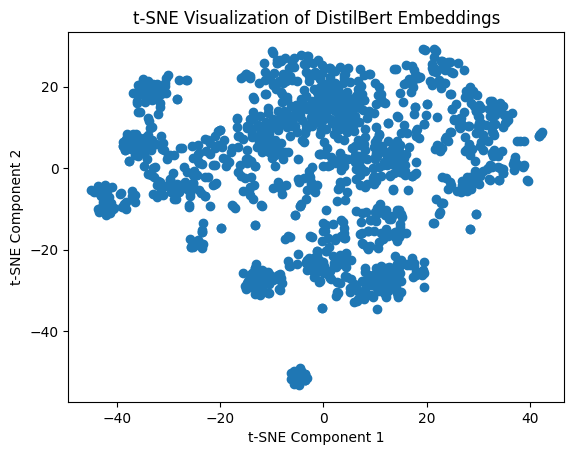

In [34]:

def visualize_embeddings_tsne(place_embeddings):
    # Convert the Series of lists to a 2D numpy array
    place_embeddings = np.vstack(place_embeddings)
    
    # Perform t-SNE to reduce to 2D
    tsne = TSNE(n_components=2, random_state=0)
    reduced_embeddings = tsne.fit_transform(place_embeddings)
    
    # Plot the 2D projections of the embeddings
    plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1])
    plt.title("t-SNE Visualization of DistilBert Embeddings")
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.show()

# Example usage with your attraction embeddings
visualize_embeddings_tsne(attraction_df['Embeddings'])
